In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [2]:
PROJECT_ROOT = Path.cwd().parents[1]

DATASET_DIR = PROJECT_ROOT / "ml" / "data" / "raw" / "kaggle"
SPLIT_DIR = PROJECT_ROOT / "ml" / "data" / "splits" / "kaggle"
MODEL_DIR = PROJECT_ROOT / "ml" / "models" / "kaggle"
RESULT_DIR = PROJECT_ROOT / "ml" / "results" / "kaggle"

SPLIT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Dataset path :", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())

Project root : /home/sivabharathi/Documents/FinalYearProject/CocoCare
Dataset path : /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/data/raw/kaggle
Dataset exists: True


In [3]:
# ============================================================
# KAGGLE DATASET AUDIT
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp", ".tif", ".tiff"
}

records = []

for image_path in DATASET_DIR.rglob("*"):
    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue

    label = image_path.parent.name

    records.append({
        "image_path": str(image_path.resolve()),
        "label": label
    })

df = pd.DataFrame(records)

print("=" * 60)
print("KAGGLE DATASET AUDIT")
print("=" * 60)

print(f"\nTotal images: {len(df)}")

print("\nClass distribution:")
print(df["label"].value_counts().sort_index())

print("\nNumber of classes:", df["label"].nunique())

print("\nClass names:")
for i, class_name in enumerate(sorted(df["label"].unique())):
    print(f"{i}: {class_name}")

KAGGLE DATASET AUDIT

Total images: 5139

Class distribution:
label
CCI_Caterpillars           990
CCI_Leaflets               795
Healthy_Leaves             123
WCLWD_DryingofLeaflets    1078
WCLWD_Flaccidity          1069
WCLWD_Yellowing           1084
Name: count, dtype: int64

Number of classes: 6

Class names:
0: CCI_Caterpillars
1: CCI_Leaflets
2: Healthy_Leaves
3: WCLWD_DryingofLeaflets
4: WCLWD_Flaccidity
5: WCLWD_Yellowing


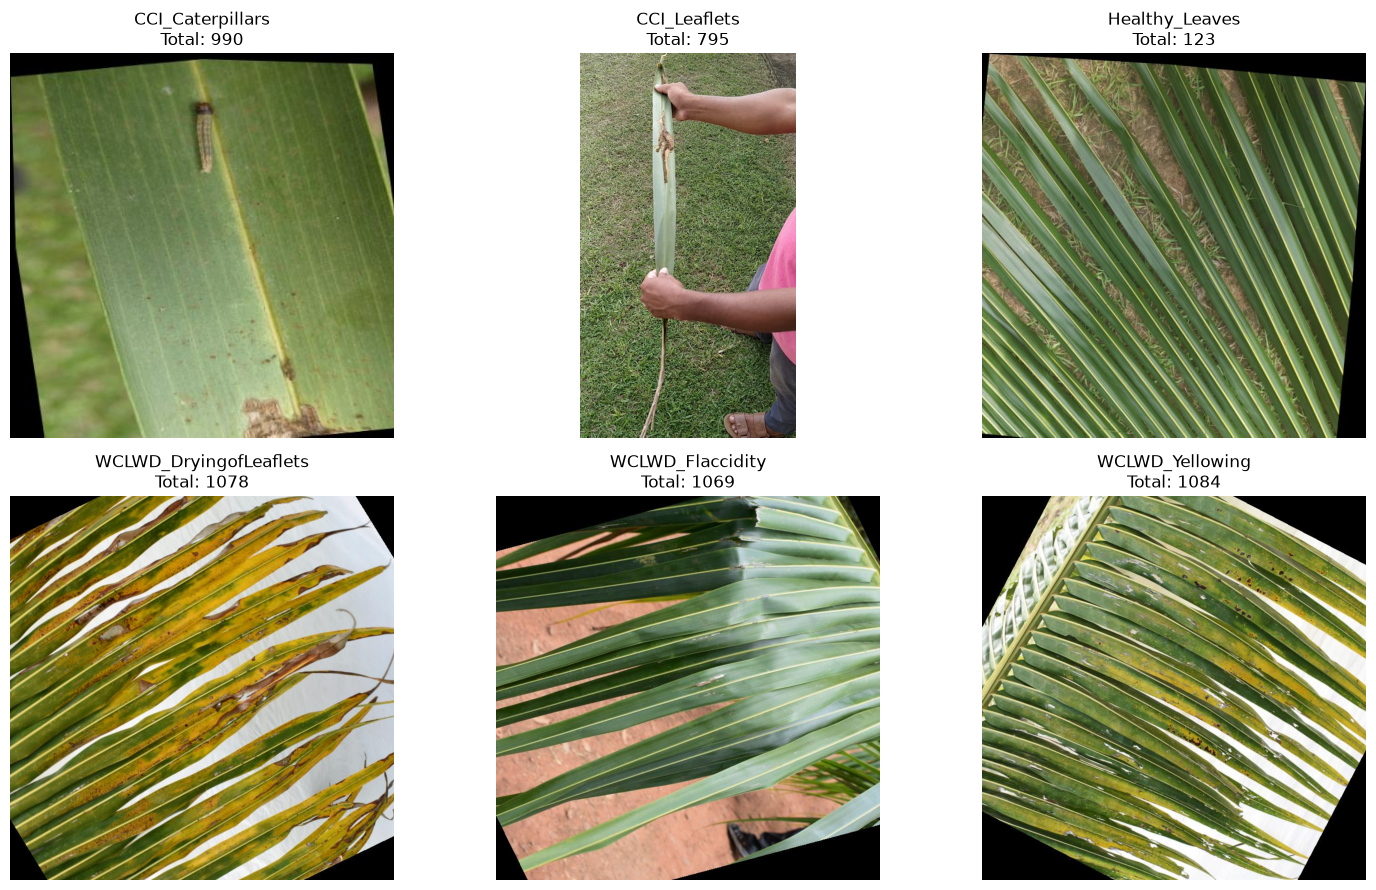

In [4]:
# ============================================================
# VISUAL INSPECTION — KAGGLE DATASET
# ============================================================

import random

random.seed(42)

class_names = sorted(df["label"].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, class_name in enumerate(class_names):

    class_df = df[df["label"] == class_name]

    sample = class_df.sample(
        n=1,
        random_state=42
    ).iloc[0]

    image_path = Path(sample["image_path"])

    image = Image.open(image_path).convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(
        f"{class_name}\nTotal: {len(class_df)}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# CREATE STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

SEED = 42

# ------------------------------------------------------------
# First split: 70% train, 30% temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

# ------------------------------------------------------------
# Second split: temporary -> 15% validation + 15% test
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("=" * 60)
print("KAGGLE DATASET SPLIT")
print("=" * 60)

print(f"\nTotal images      : {len(df)}")
print(f"Training images   : {len(train_df)}")
print(f"Validation images : {len(val_df)}")
print(f"Test images       : {len(test_df)}")

print("\n" + "-" * 60)
print("TRAIN DISTRIBUTION")
print("-" * 60)
print(train_df["label"].value_counts().sort_index())

print("\n" + "-" * 60)
print("VALIDATION DISTRIBUTION")
print("-" * 60)
print(val_df["label"].value_counts().sort_index())

print("\n" + "-" * 60)
print("TEST DISTRIBUTION")
print("-" * 60)
print(test_df["label"].value_counts().sort_index())

KAGGLE DATASET SPLIT

Total images      : 5139
Training images   : 3597
Validation images : 771
Test images       : 771

------------------------------------------------------------
TRAIN DISTRIBUTION
------------------------------------------------------------
label
CCI_Caterpillars          693
CCI_Leaflets              556
Healthy_Leaves             86
WCLWD_DryingofLeaflets    755
WCLWD_Flaccidity          748
WCLWD_Yellowing           759
Name: count, dtype: int64

------------------------------------------------------------
VALIDATION DISTRIBUTION
------------------------------------------------------------
label
CCI_Caterpillars          149
CCI_Leaflets              120
Healthy_Leaves             18
WCLWD_DryingofLeaflets    161
WCLWD_Flaccidity          160
WCLWD_Yellowing           163
Name: count, dtype: int64

------------------------------------------------------------
TEST DISTRIBUTION
------------------------------------------------------------
label
CCI_Caterpillars    

In [6]:
# ============================================================
# SAVE TRAIN / VALIDATION / TEST CSV FILES
# ============================================================

train_csv = SPLIT_DIR / "train.csv"
val_csv = SPLIT_DIR / "val.csv"
test_csv = SPLIT_DIR / "test.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("=" * 60)
print("SPLITS SAVED")
print("=" * 60)

print(f"\nTrain CSV      : {train_csv}")
print(f"Validation CSV : {val_csv}")
print(f"Test CSV       : {test_csv}")

print("\nFiles exist:")
print("train.csv:", train_csv.exists())
print("val.csv  :", val_csv.exists())
print("test.csv :", test_csv.exists())

SPLITS SAVED

Train CSV      : /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/data/splits/kaggle/train.csv
Validation CSV : /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/data/splits/kaggle/val.csv
Test CSV       : /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/data/splits/kaggle/test.csv

Files exist:
train.csv: True
val.csv  : True
test.csv : True


In [7]:
# ============================================================
# CLASS MAPPING + TENSORFLOW DATA PIPELINE
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Class mapping
# ------------------------------------------------------------

class_names = sorted(df["label"].unique())

CLASS_TO_INDEX = {
    name: i
    for i, name in enumerate(class_names)
}

INDEX_TO_CLASS = {
    i: name
    for name, i in CLASS_TO_INDEX.items()
}

print("\nClass mapping:")

for index, name in INDEX_TO_CLASS.items():
    print(f"{index} -> {name}")

# ------------------------------------------------------------
# Image loader
# ------------------------------------------------------------

AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


# ------------------------------------------------------------
# DataFrame -> TensorFlow Dataset
# ------------------------------------------------------------

def dataframe_to_dataset(dataframe, shuffle=False):

    paths = dataframe["image_path"].values

    labels = dataframe["label"].map(
        CLASS_TO_INDEX
    ).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_ds = dataframe_to_dataset(
    train_df,
    shuffle=True
)

val_ds = dataframe_to_dataset(
    val_df,
    shuffle=False
)

test_ds = dataframe_to_dataset(
    test_df,
    shuffle=False
)


# ------------------------------------------------------------
# Verify one batch
# ------------------------------------------------------------

images, labels = next(iter(train_ds))

print("\n" + "=" * 60)
print("PIPELINE CHECK")
print("=" * 60)

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Image dtype       :", images.dtype)
print("Label dtype       :", labels.dtype)

print(
    "Pixel range       :",
    float(tf.reduce_min(images)),
    "to",
    float(tf.reduce_max(images))
)

I0000 00:00:1790516982.897682  264909 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790516982.941284  264909 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/sivabharathi/miniconda3/envs/mldlenv/lib/python3.12/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
I0000 00:00:1790516984.338154  264909 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
GPU: []

Class mapping:
0 -> CCI_Caterpillars
1 -> CCI_Leaflets
2 -> Healthy_Leaves
3 -> WCLWD_DryingofLeaflets
4 -> WCLWD_Flaccidity
5 -> WCLWD_Yellowing


E0000 00:00:1790516984.681687  264909 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1790516994.793819  268934 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3165 of 3597
I0000 00:00:1790516996.387901  268934 shuffle_dataset_op.cc:483] Shuffle buffer filled.



PIPELINE CHECK
Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)
Image dtype       : <dtype: 'float32'>
Label dtype       : <dtype: 'int64'>
Pixel range       : 0.0 to 255.0


In [8]:
# ============================================================
# CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

train_class_indices = np.array([
    CLASS_TO_INDEX[label]
    for label in train_df["label"]
])

classes = np.unique(train_class_indices)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_class_indices
)

class_weights = {
    int(class_index): float(weight)
    for class_index, weight in zip(classes, weights)
}

print("=" * 60)
print("CLASS WEIGHTS")
print("=" * 60)

for class_index, weight in class_weights.items():
    print(
        f"{class_index} -> "
        f"{INDEX_TO_CLASS[class_index]:30s} : "
        f"{weight:.4f}"
    )

CLASS WEIGHTS
0 -> CCI_Caterpillars               : 0.8651
1 -> CCI_Leaflets                   : 1.0782
2 -> Healthy_Leaves                 : 6.9709
3 -> WCLWD_DryingofLeaflets         : 0.7940
4 -> WCLWD_Flaccidity               : 0.8015
5 -> WCLWD_Yellowing                : 0.7899


In [9]:
# ============================================================
# BUILD MOBILENETV3SMALL MODEL
# ============================================================

# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")


# ------------------------------------------------------------
# MobileNetV3Small backbone
# ------------------------------------------------------------

base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True
)

# Freeze backbone for Stage 1
base_model.trainable = False


# ------------------------------------------------------------
# Classification head
# ------------------------------------------------------------

inputs = keras.Input(
    shape=(*IMAGE_SIZE, 3),
    name="image"
)

x = data_augmentation(
    inputs,
    training=True
)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(
    0.30
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)


# ------------------------------------------------------------
# Final model
# ------------------------------------------------------------

model = keras.Model(
    inputs,
    outputs,
    name="cococare_kaggle_mobilenetv3"
)


# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

model.summary()

Model: "cococare_kaggle_mobilenetv3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         3,462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 942,582 (3.60 MB)

 Trainable params: 3,462 (13.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [10]:

# ============================================================
# COMPILE STAGE 1
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("=" * 60)
print("STAGE 1 COMPILED")
print("=" * 60)

print("Optimizer     : Adam")
print("Learning rate : 1e-3")
print("Loss          : SparseCategoricalCrossentropy")
print("Metric        : Accuracy")
print("Class weights : Enabled")

STAGE 1 COMPILED
Optimizer     : Adam
Learning rate : 1e-3
Loss          : SparseCategoricalCrossentropy
Metric        : Accuracy
Class weights : Enabled


In [11]:
# ============================================================
# STAGE 1 CALLBACKS
# ============================================================

checkpoint_path = MODEL_DIR / "kaggle_stage1_best.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("=" * 60)
print("STAGE 1 CALLBACKS READY")
print("=" * 60)

print("Checkpoint :", checkpoint_path)
print("Monitor    : val_loss")
print("Early stop : patience = 4")
print("LR reduce  : factor = 0.3")

STAGE 1 CALLBACKS READY
Checkpoint : /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras
Monitor    : val_loss
Early stop : patience = 4
LR reduce  : factor = 0.3


In [12]:
# ============================================================
# TRAIN STAGE 1
# ============================================================

EPOCHS_HEAD = 10

print("=" * 60)
print("STARTING KAGGLE STAGE 1 TRAINING")
print("=" * 60)

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weights,
    callbacks=callbacks
)

print("\n" + "=" * 60)
print("STAGE 1 TRAINING COMPLETE")
print("=" * 60)

STARTING KAGGLE STAGE 1 TRAINING
Epoch 1/10


/home/sivabharathi/miniconda3/envs/mldlenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790517242.874460  269314 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3332 of 3597
I0000 00:00:1790517243.837602  269314 shuffle_dataset_op.cc:483] Shuffle buffer filled.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6444 - loss: 0.9237
Epoch 1: val_loss improved from None to 0.34728, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras

Epoch 1: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 65s 440ms/step - accuracy: 0.6444 - loss: 0.9237 - val_accuracy: 0.8975 - val_loss: 0.3473 - learning_rate: 0.0010
Epoch 2/10


I0000 00:00:1790517303.571607  269434 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 2521 of 3597
I0000 00:00:1790517308.929174  269434 shuffle_dataset_op.cc:483] Shuffle buffer filled.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8579 - loss: 0.3824
Epoch 2: val_loss improved from 0.34728 to 0.22712, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras

Epoch 2: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 70s 487ms/step - accuracy: 0.8579 - loss: 0.3824 - val_accuracy: 0.9274 - val_loss: 0.2271 - learning_rate: 0.0010
Epoch 3/10


...

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.9469 - loss: 0.1441
Epoch 8: val_loss improved from 0.11979 to 0.10919, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras

Epoch 8: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 87s 598ms/step - accuracy: 0.9469 - loss: 0.1441 - val_accuracy: 0.9650 - val_loss: 0.1092 - learning_rate: 0.0010
Epoch 9/10


I0000 00:00:1790517880.042850  270355 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 2069 of 3597
I0000 00:00:1790517887.576531  270355 shuffle_dataset_op.cc:483] Shuffle buffer filled.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9522 - loss: 0.1377
Epoch 9: val_loss improved from 0.10919 to 0.09657, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras

Epoch 9: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 87s 612ms/step - accuracy: 0.9522 - loss: 0.1377 - val_accuracy: 0.9650 - val_loss: 0.0966 - learning_rate: 0.0010
Epoch 10/10


I0000 00:00:1790517966.692655  270481 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1928 of 3597
I0000 00:00:1790517974.929116  270481 shuffle_dataset_op.cc:483] Shuffle buffer filled.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.9469 - loss: 0.1433
Epoch 10: val_loss improved from 0.09657 to 0.09371, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras

Epoch 10: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage1_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 85s 588ms/step - accuracy: 0.9469 - loss: 0.1433 - val_accuracy: 0.9741 - val_loss: 0.0937 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

STAGE 1 TRAINING COMPLETE


In [13]:
# ============================================================
# STAGE 1 — TEST SET EVALUATION
# ============================================================

print("=" * 60)
print("KAGGLE STAGE 1 TEST EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n" + "=" * 60)
print("STAGE 1 TEST RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4%}")

KAGGLE STAGE 1 TEST EVALUATION
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 339ms/step - accuracy: 0.9715 - loss: 0.0942

STAGE 1 TEST RESULTS
Test Loss     : 0.0942
Test Accuracy : 97.1466%


In [14]:
# ============================================================
# STAGE 1 — CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n" + "=" * 60)
print("KAGGLE STAGE 1 CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


KAGGLE STAGE 1 CLASSIFICATION REPORT
                        precision    recall  f1-score   support

      CCI_Caterpillars     1.0000    1.0000    1.0000       148
          CCI_Leaflets     1.0000    1.0000    1.0000       119
        Healthy_Leaves     0.7308    1.0000    0.8444        19
WCLWD_DryingofLeaflets     0.9753    0.9753    0.9753       162
      WCLWD_Flaccidity     1.0000    0.9130    0.9545       161
       WCLWD_Yellowing     0.9349    0.9753    0.9547       162

              accuracy                         0.9715       771
             macro avg     0.9402    0.9773    0.9548       771
          weighted avg     0.9745    0.9715    0.9720       771


CONFUSION MATRIX
[[148   0   0   0   0   0]
 [  0 119   0   0   0   0]
 [  0   0  19   0   0   0]
 [  0   0   0 158   0   4]
 [  0   0   7   0 147   7]
 [  0   0   0   4   0 158]]


In [15]:
# ============================================================
# STAGE 2 — UNFREEZE LAST 30 LAYERS
# ============================================================

base_model.trainable = True

# Freeze earlier layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("=" * 60)
print("STAGE 2 FINE-TUNING CONFIGURATION")
print("=" * 60)

trainable_count = sum(
    1 for layer in model.layers
    if layer.trainable
)

total_count = len(model.layers)

print(f"Trainable model layers : {trainable_count}")
print(f"Total model layers     : {total_count}")

print("\nLast 30 backbone layers are being fine-tuned.")
print("BatchNormalization layers remain frozen.")

STAGE 2 FINE-TUNING CONFIGURATION
Trainable model layers : 6
Total model layers     : 6

Last 30 backbone layers are being fine-tuned.
BatchNormalization layers remain frozen.


In [17]:
# ============================================================
# COMPILE STAGE 2
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("=" * 60)
print("STAGE 2 COMPILED")
print("=" * 60)

print("Learning rate : 1e-5")
print("Optimizer     : Adam")

STAGE 2 COMPILED
Learning rate : 1e-5
Optimizer     : Adam


In [18]:
# ============================================================
# STAGE 2 CALLBACKS
# ============================================================

fine_tune_checkpoint = MODEL_DIR / "kaggle_stage2_best.keras"

fine_tune_callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath=fine_tune_checkpoint,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Stage 2 callbacks ready.")
print("Checkpoint:", fine_tune_checkpoint)

Stage 2 callbacks ready.
Checkpoint: /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras


In [19]:
# ============================================================
# TRAIN STAGE 2 — FINE-TUNING
# ============================================================

EPOCHS_FINE = 15

print("=" * 60)
print("STARTING KAGGLE STAGE 2 FINE-TUNING")
print("=" * 60)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks
)

print("\n" + "=" * 60)
print("STAGE 2 FINE-TUNING COMPLETE")
print("=" * 60)

STARTING KAGGLE STAGE 2 FINE-TUNING
Epoch 1/15


/home/sivabharathi/miniconda3/envs/mldlenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790518994.988507  272110 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 2296 of 3597
I0000 00:00:1790519000.416721  272110 shuffle_dataset_op.cc:483] Shuffle buffer filled.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.9513 - loss: 0.1183
Epoch 1: val_loss improved from None to 0.07956, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras

Epoch 1: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 88s 558ms/step - accuracy: 0.9513 - loss: 0.1183 - val_accuracy: 0.9754 - val_loss: 0.0796 - learning_rate: 1.0000e-05
Epoch 2/15


I0000 00:00:1790519073.435713  272278 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 2480 of 3597
I0000 00:00:1790519077.993769  272278 shuffle_dataset_op.cc:483] Shuffle buffer filled.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9600 - loss: 0.0970
Epoch 2: val_loss improved from 0.07956 to 0.07059, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras

Epoch 2: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 75s 535ms/step - accuracy: 0.9600 - loss: 0.0970 - val_accuracy: 0.9805 - val_loss: 0.0706 - learning_rate: 1.0000e-05
Epoch 3/15


...

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9741 - loss: 0.0584
Epoch 13: val_loss improved from 0.04369 to 0.04291, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras

Epoch 13: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 92s 658ms/step - accuracy: 0.9741 - loss: 0.0584 - val_accuracy: 0.9883 - val_loss: 0.0429 - learning_rate: 1.0000e-05
Epoch 14/15


I0000 00:00:1790520005.810549  279628 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1729 of 3597
I0000 00:00:1790520015.830739  279628 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3136 of 3597
I0000 00:00:1790520019.679285  279628 shuffle_dataset_op.cc:483] Shuffle buffer filled.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9814 - loss: 0.0483
Epoch 14: val_loss improved from 0.04291 to 0.03973, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras

Epoch 14: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 88s 565ms/step - accuracy: 0.9814 - loss: 0.0483 - val_accuracy: 0.9870 - val_loss: 0.0397 - learning_rate: 1.0000e-05
Epoch 15/15


I0000 00:00:1790520093.935352  279820 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 2480 of 3597
I0000 00:00:1790520099.254375  279820 shuffle_dataset_op.cc:483] Shuffle buffer filled.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9847 - loss: 0.0434
Epoch 15: val_loss improved from 0.03973 to 0.03925, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras

Epoch 15: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_stage2_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 73s 510ms/step - accuracy: 0.9847 - loss: 0.0434 - val_accuracy: 0.9883 - val_loss: 0.0393 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 15.

STAGE 2 FINE-TUNING COMPLETE


In [20]:
# ============================================================
# STAGE 2 — TEST SET EVALUATION
# ============================================================

print("=" * 60)
print("KAGGLE STAGE 2 TEST EVALUATION")
print("=" * 60)

test_loss_stage2, test_accuracy_stage2 = model.evaluate(
    test_ds,
    verbose=1
)

print("\n" + "=" * 60)
print("STAGE 2 TEST RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss_stage2:.4f}")
print(f"Test Accuracy : {test_accuracy_stage2:.4%}")

KAGGLE STAGE 2 TEST EVALUATION
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/step - accuracy: 0.9896 - loss: 0.0338

STAGE 2 TEST RESULTS
Test Loss     : 0.0338
Test Accuracy : 98.9624%


In [21]:
# ============================================================
# STAGE 2 — CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

y_true_stage2 = []
y_pred_stage2 = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true_stage2.extend(labels.numpy())
    y_pred_stage2.extend(predicted_classes)

y_true_stage2 = np.array(y_true_stage2)
y_pred_stage2 = np.array(y_pred_stage2)

print("=" * 60)
print("KAGGLE STAGE 2 CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true_stage2,
        y_pred_stage2,
        target_names=class_names,
        digits=4
    )
)

cm_stage2 = confusion_matrix(
    y_true_stage2,
    y_pred_stage2
)

print("\n" + "=" * 60)
print("STAGE 2 CONFUSION MATRIX")
print("=" * 60)

print(cm_stage2)

KAGGLE STAGE 2 CLASSIFICATION REPORT
                        precision    recall  f1-score   support

      CCI_Caterpillars     1.0000    1.0000    1.0000       148
          CCI_Leaflets     1.0000    1.0000    1.0000       119
        Healthy_Leaves     0.9048    1.0000    0.9500        19
WCLWD_DryingofLeaflets     0.9876    0.9815    0.9845       162
      WCLWD_Flaccidity     1.0000    0.9814    0.9906       161
       WCLWD_Yellowing     0.9756    0.9877    0.9816       162

              accuracy                         0.9896       771
             macro avg     0.9780    0.9918    0.9845       771
          weighted avg     0.9899    0.9896    0.9897       771


STAGE 2 CONFUSION MATRIX
[[148   0   0   0   0   0]
 [  0 119   0   0   0   0]
 [  0   0  19   0   0   0]
 [  0   0   0 159   0   3]
 [  0   0   2   0 158   1]
 [  0   0   0   2   0 160]]


In [22]:
# ============================================================
# SAVE FINAL KAGGLE MODEL
# ============================================================

final_model_path = MODEL_DIR / "kaggle_final_best.keras"

model.save(final_model_path)

print("=" * 60)
print("FINAL KAGGLE MODEL SAVED")
print("=" * 60)

print("Path:", final_model_path)
print("Exists:", final_model_path.exists())
print("Size:", f"{final_model_path.stat().st_size / (1024 * 1024):.2f} MB")

FINAL KAGGLE MODEL SAVED
Path: /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/kaggle_final_best.keras
Exists: True
Size: 8.64 MB


In [23]:
# ============================================================
# SAVE CLASS NAMES
# ============================================================

class_names_path = MODEL_DIR / "class_names.txt"

with open(class_names_path, "w") as f:
    for class_name in class_names:
        f.write(class_name + "\n")

print("=" * 60)
print("CLASS NAMES SAVED")
print("=" * 60)

print("Path:", class_names_path)
print("Exists:", class_names_path.exists())

print("\nClass mapping:")
for i, name in enumerate(class_names):
    print(f"{i} -> {name}")

CLASS NAMES SAVED
Path: /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/class_names.txt
Exists: True

Class mapping:
0 -> CCI_Caterpillars
1 -> CCI_Leaflets
2 -> Healthy_Leaves
3 -> WCLWD_DryingofLeaflets
4 -> WCLWD_Flaccidity
5 -> WCLWD_Yellowing


In [24]:
# ============================================================
# CONVERT FINAL KAGGLE MODEL TO TFLITE
# ============================================================

print("=" * 60)
print("TFLITE CONVERSION — KAGGLE MODEL")
print("=" * 60)

converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

tflite_path = MODEL_DIR / "coconut_health_pest_model.tflite"

tflite_path.write_bytes(tflite_model)

print("\nConversion successful!")

print("Final Keras model :",
      final_model_path)

print("Class names       :",
      class_names_path)

print("TFLite model      :",
      tflite_path)

print(
    "TFLite size       :",
    f"{tflite_path.stat().st_size / (1024 * 1024):.2f} MB"
)

print("\nExists:")
print("TFLite:", tflite_path.exists())

print("\n" + "=" * 60)
print("COCOCARE KAGGLE MODEL READY")
print("=" * 60)

TFLITE CONVERSION — KAGGLE MODEL
INFO:tensorflow:Assets written to: /tmp/tmplixrez0g/assets


INFO:tensorflow:Assets written to: /tmp/tmplixrez0g/assets


Saved artifact at '/tmp/tmplixrez0g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133158516961936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133158516964432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133158516964240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133158516962704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133158516965008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133158516950992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133158516964048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133158516964816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133158516964624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133158516965200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133158482347600: Tens

W0000 00:00:1790521216.838749  264909 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790521216.839165  264909 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790521216.842025  264909 reader.cc:83] Reading SavedModel from: /tmp/tmplixrez0g
I0000 00:00:1790521216.851107  264909 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790521216.851128  264909 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmplixrez0g
I0000 00:00:1790521216.935802  264909 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790521216.951827  264909 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790521217.513762  264909 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmplixrez0g
I0000 00:00:1790521217.669542  264909 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 827527 microseconds.
I0000 00:00:1790521217.861047  26490